In [1]:
%load_ext autoreload
%autoreload 2

import os
import os.path as osp
import csv
import time

import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from hydra import compose, initialize
from hydra.core.global_hydra import GlobalHydra  # Import GlobalHydra explicitly
from hydra.utils import instantiate
import numpy as np
from tqdm.auto import tqdm


from ogbench.utils.config_resolvers import (
    get_default_transform,
    get_monitor_metric,
    get_monitor_mode,
    infer_in_channels,
)

# Clear GlobalHydra instance if already initialized
if GlobalHydra().is_initialized():
    GlobalHydra().clear()

initialize(config_path="../configs", job_name="job")

/home/lcornelis/anaconda3/envs/bgbench/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3003760/269507007.py:30: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../configs", job_name="job")


hydra.initialize()

In [2]:
# OPTIONAL: Diagnostic tool to check which processed .pt files exist
# Run this if you want to verify files exist before loading

import os
import os.path as osp
import time

def check_processed_files():
    """Check which processed .pt files exist on disk."""
    project_root = os.environ.get('PROJECT_ROOT', '/home/lcornelis/code/bgbench')
    root1 = osp.join(project_root, "run_data", "data", "omics")
    root2 = osp.join(project_root, "run_data", "omics")
    
    root = root1 if osp.exists(root1) else root2
    datasets = ["motrpac", "addneuromed", "parkinsons"]
    thresholds = {"motrpac": 0.0229, "addneuromed": 0.1792, "parkinsons": 0.0463}
    ratios = ["full", "0.8", "0.5"]
    method = "variance"
    train_split = 0.7
    
    print("Checking for processed .pt files...")
    print(f"Root: {root}\n")
    
    found = []
    missing = []
    
    for dataset_name in datasets:
        adj_thresh = thresholds[dataset_name]
        for ratio in ratios:
            processed_path = osp.join(
                root, dataset_name,
                f"adj_thresh_{adj_thresh}",
                method,
                f"p_{ratio}",
                f"train_split_{train_split}",
                "processed",
                "data.pt"
            )
            if osp.exists(processed_path):
                size_mb = osp.getsize(processed_path) / (1024 * 1024)
                found.append((dataset_name, ratio, size_mb))
            else:
                missing.append((dataset_name, ratio))
    
    print(f"✓ Found {len(found)} processed files (will load quickly):")
    for ds, ratio, size in found:
        print(f"  - {ds}_p{ratio}: {size:.1f} MB")
    
    if missing:
        print(f"\n✗ Missing {len(missing)} files (will process on first load - takes minutes):")
        for ds, ratio in missing:
            print(f"  - {ds}_p{ratio}")

# Uncomment to run:
# check_processed_files()


In [3]:
# OPTIONAL: Quick test with fewer combinations
# Uncomment this cell to test with just one node_sample_ratio first (much faster!)
# Then run the full analysis in Cell 2

# QUICK_TEST = True  # Set to True for quick test
# if QUICK_TEST:
#     node_sample_ratios = [1.0]  # Just test with full nodes first
#     print("Running quick test with node_sample_ratio=1.0 only")


In [4]:
def load_dataset(dataset_name, adj_thresh=0.5, node_sample_ratio="full"):
    """
    Load the dataset with a specified adjacency threshold and node_sample_ratio.
    The dataset will be loaded from saved .pt files if they exist, otherwise
    it will download and process (which takes time).
    """
    print(f"Loading {dataset_name} (adj_thresh={adj_thresh}, p={node_sample_ratio})...")
    start_time = time.time()
    
    cfg = compose(
        config_name="train.yaml",
        overrides=[
            "model=gatv2",
            f"dataset={dataset_name}",
            f"dataset.loader.parameters.adjacency_threshold={adj_thresh}",
            f"dataset.loader.parameters.node_sample_ratio={node_sample_ratio}",
        ],
        return_hydra_config=True,
    )
    
    # Check if processed file exists
    # IMPORTANT: Use the actual data_dir from the loader config, which includes 'omics/'
    import os.path as osp
    # The loader's data_dir should be: run_data/data/omics (from config)
    loader_data_dir = str(cfg.dataset.loader.parameters.data_dir)
    method = "variance"
    node_ratio_str = node_sample_ratio if node_sample_ratio != "full" else "full"
    train_split = 0.7
    
    processed_path = osp.join(
        loader_data_dir,
        dataset_name,
        f"adj_thresh_{adj_thresh}",
        method,
        f"p_{node_ratio_str}",
        f"train_split_{train_split}",
        "processed",
        "data.pt"
    )
    
    file_exists = osp.exists(processed_path)
    if file_exists:
        file_size = osp.getsize(processed_path) / (1024 * 1024)
        print(f"  → Found processed file ({file_size:.1f} MB) - should load quickly")
        print(f"  → Path: {processed_path}")
    else:
        print(f"  ⚠️  Processed file NOT found - will download/process (takes minutes)")
        print(f"  → Expected: {processed_path}")
    
    loader = instantiate(cfg.dataset.loader)
    
    # IMPORTANT: Verify the file exists before loading
    # This helps catch if InMemoryDataset is re-processing unnecessarily
    if file_exists:
        import os
        if not os.path.exists(processed_path):
            print(f"  ⚠️  ERROR: File check said it exists but now it doesn't!")
            print(f"  ⚠️  This suggests a path mismatch issue")
        else:
            # Verify file is readable
            try:
                import torch
                test_load = torch.load(processed_path, map_location='cpu')
                print(f"  → Verified file is readable (test load successful)")
            except Exception as e:
                print(f"  ⚠️  WARNING: File exists but can't be loaded: {e}")
    
    # Load dataset - watch for download/process messages
    print(f"  → Calling loader.load_dataset()...")
    print(f"  → If you see 'Downloading' or 'Processing' messages, it's re-processing!")
    dataset = loader.load_dataset()
    load_time = time.time() - start_time
    
    if file_exists:
        if load_time > 10:
            print(f"  ⚠️  PROBLEM: File exists but took {load_time:.1f}s to load!")
            print(f"  ⚠️  It's likely re-processing instead of loading from disk")
            print(f"  ⚠️  Check the output above for 'Downloading' or 'Processing' messages")
        else:
            print(f"  ✓ Loaded in {load_time:.2f}s")
    else:
        print(f"  ✓ Processed in {load_time/60:.1f} minutes")
    
    return dataset


In [5]:
# Enhanced graph statistics function with additional metrics
def get_comprehensive_graph_stats(dataset):
    """
    Get comprehensive statistics of the graph including additional metrics
    that may explain performance differences.
    """
    graph = None
    
    # First, try to access the processed data directly from the dataset
    try:
        if hasattr(dataset, 'data') and dataset.data is not None:
            # Use the processed data from the dataset
            data = dataset[0]  # Get the first (and only) graph
            edge_index = data.edge_index
            num_nodes = data.x.shape[0]

            # Convert edge_index to numpy if it's a torch tensor
            if hasattr(edge_index, 'numpy'):
                edge_list = edge_index.t().numpy()
            elif hasattr(edge_index, 'cpu'):
                edge_list = edge_index.cpu().numpy().T
            else:
                edge_list = edge_index.T

            # Create graph from edge_index
            graph = nx.Graph()
            graph.add_nodes_from(range(num_nodes))
            graph.add_edges_from(edge_list)
    except Exception as e:
        print(f"Could not access processed data: {e}")
    
    # If that didn't work, try to load from raw_dir
    if graph is None:
        try:
            if hasattr(dataset, 'raw_dir'):
                adj_path = osp.join(dataset.raw_dir, 'adj_matrix.npy')
                if osp.exists(adj_path):
                    adj_matrix = np.load(adj_path)
                    graph = nx.from_numpy_array(adj_matrix)
                    graph.remove_edges_from(nx.selfloop_edges(graph))
        except Exception as e:
            print(f"Could not load from raw_dir: {e}")
    
    # Last resort: try to construct the path manually
    if graph is None:
        try:
            root = "/home/lcornelis/code/bgbench/run_data/omics/"
            # Handle node_sample_ratio formatting
            node_ratio = dataset.node_sample_ratio
            if node_ratio == 1.0 or node_ratio == 'full':
                node_ratio_str = 'full'
            else:
                node_ratio_str = str(node_ratio)
            
            name = osp.join(
                root,
                f"{dataset.data_name}",
                f"adj_thresh_{dataset.adjacency_threshold}",
                f"{dataset.method}",
                f"p_{node_ratio_str}",
                f"train_split_{dataset.train_val_test_split[0]}",
                "raw/adj_matrix.npy",
            )
            adj_matrix = np.load(name)
            graph = nx.from_numpy_array(adj_matrix)
            graph.remove_edges_from(nx.selfloop_edges(graph))
        except Exception as e:
            raise FileNotFoundError(
                f"Could not load adjacency matrix. Tried:\n"
                f"1. Processed data from dataset[0]\n"
                f"2. raw_dir: {getattr(dataset, 'raw_dir', 'N/A')}\n"
                f"3. Constructed path: {name}\n"
                f"Error: {e}"
            )

    # Basic statistics
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    avg_degree = np.mean([d for _, d in graph.degree()]) if num_nodes > 0 else 0.0
    density = nx.density(graph)
    number_connected_components = nx.number_connected_components(graph)
    
    # Get the largest connected component for additional metrics
    if number_connected_components > 0:
        largest_cc = max(nx.connected_components(graph), key=len)
        largest_cc_graph = graph.subgraph(largest_cc)
        largest_cc_size = len(largest_cc)
        
        # Average path length (only for largest connected component)
        # WARNING: This is VERY slow for large graphs (O(n*m))
        if largest_cc_size > 1:
            try:
                print(f"    Computing average path length (slow for large graphs)...")
                path_start = time.time()
                avg_path_length = nx.average_shortest_path_length(largest_cc_graph)
                print(f"    Average path length computed in {time.time() - path_start:.2f}s")
            except Exception as e:
                print(f"    Could not compute average path length: {e}")
                avg_path_length = np.nan
        else:
            avg_path_length = 0.0
            
        # Clustering coefficient
        print(f"    Computing clustering coefficient...")
        cluster_start = time.time()
        clustering_coeff = nx.average_clustering(largest_cc_graph)
        print(f"    Clustering coefficient computed in {time.time() - cluster_start:.2f}s")
        
        # Diameter (longest shortest path)
        # WARNING: This is VERY slow for large graphs
        if largest_cc_size > 1:
            try:
                print(f"    Computing diameter (very slow for large graphs)...")
                diam_start = time.time()
                diameter = nx.diameter(largest_cc_graph)
                print(f"    Diameter computed in {time.time() - diam_start:.2f}s")
            except Exception as e:
                print(f"    Could not compute diameter: {e}")
                diameter = np.nan
        else:
            diameter = 0.0
    else:
        largest_cc_size = 0
        avg_path_length = np.nan
        clustering_coeff = 0.0
        diameter = np.nan
    
    # Degree distribution statistics
    degrees = [d for _, d in graph.degree()]
    if len(degrees) > 0:
        degree_std = np.std(degrees)
        degree_median = np.median(degrees)
        degree_max = np.max(degrees)
        degree_min = np.min(degrees)
    else:
        degree_std = 0.0
        degree_median = 0.0
        degree_max = 0.0
        degree_min = 0.0
    
    # Ratio of largest component to total nodes
    largest_cc_ratio = largest_cc_size / num_nodes if num_nodes > 0 else 0.0

    return {
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "avg_degree": avg_degree,
        "density": density,
        "number_connected_components": number_connected_components,
        "largest_cc_size": largest_cc_size,
        "largest_cc_ratio": largest_cc_ratio,
        "avg_path_length": avg_path_length,
        "clustering_coefficient": clustering_coeff,
        "diameter": diameter,
        "degree_std": degree_std,
        "degree_median": degree_median,
        "degree_max": degree_max,
        "degree_min": degree_min,
    }


In [6]:
# Load all three datasets with their specific adjacency thresholds
# Analyze with multiple node_sample_ratio values: 1.0, 0.8, and 0.5
# NOTE: Datasets should load from saved .pt files (a few seconds each)
#       Stats are saved to CSV and reloaded if they exist (avoids slow recomputation)

import os.path as osp

dataset_thresholds = {
    "motrpac": 0.0229,
    "addneuromed": 0.1792,
    "parkinsons": 0.0463
}
node_sample_ratios = [1.0, 0.8, 0.5]
datasets_to_analyze = ["motrpac", "addneuromed", "parkinsons"]

# CSV file to save/load stats
stats_csv_path = "./stats/dataset_stats.csv"
os.makedirs(osp.dirname(stats_csv_path), exist_ok=True)

# Try to load existing stats from CSV
all_dataset_stats = {}
if osp.exists(stats_csv_path):
    print(f"Loading existing stats from {stats_csv_path}...")
    try:
        df = pd.read_csv(stats_csv_path, index_col=0)
        for idx, row in df.iterrows():
            # Convert back to dict, handling NaN values
            stats = row.to_dict()
            # Convert string 'nan' back to np.nan for numeric fields
            for key in ['avg_path_length', 'diameter']:
                if key in stats and (pd.isna(stats[key]) or stats[key] == 'nan'):
                    stats[key] = np.nan
                elif key in stats:
                    stats[key] = float(stats[key])
            all_dataset_stats[idx] = stats
        print(f"✓ Loaded {len(all_dataset_stats)} datasets from CSV")
    except Exception as e:
        print(f"⚠️  Could not load from CSV: {e}")
        print("  Will recompute stats...")
        all_dataset_stats = {}

loaded_datasets = {}  # Store dataset objects for later use

for dataset_name in datasets_to_analyze:
    adj_thresh = dataset_thresholds[dataset_name]
    for node_ratio in node_sample_ratios:
        key = f"{dataset_name}_p{node_ratio}"
        
        # Skip if stats already exist
        if key in all_dataset_stats:
            print(f"\n⏭️  Skipping {key} (stats already loaded from CSV)")
            continue
        
        print(f"\nLoading {dataset_name} with adj_thresh={adj_thresh}, node_ratio={node_ratio}...")
        try:
            # Convert node_ratio to string format for Hydra override
            node_ratio_str = "full" if node_ratio == 1.0 else str(node_ratio)
            
            # Load dataset (should load from .pt file if it exists)
            dataset = load_dataset(dataset_name, adj_thresh=adj_thresh, node_sample_ratio=node_ratio_str)
            loaded_datasets[key] = dataset  # Store the dataset object
            
            # Compute stats (this can be slow for large graphs)
            print(f"  → Computing graph statistics (this may take a while for large graphs)...")
            stats_start = time.time()
            stats = get_comprehensive_graph_stats(dataset)
            stats_time = time.time() - stats_start
            print(f"  → Stats computed in {stats_time:.2f}s")
            stats["dataset_name"] = dataset_name
            stats["adj_thresh"] = adj_thresh
            stats["node_sample_ratio"] = node_ratio
            all_dataset_stats[key] = stats
            
            print(f"✓ {key} loaded and stats computed")
        except Exception as e:
            print(f"✗ Error loading {key}: {e}")
            import traceback
            traceback.print_exc()

# Save stats to CSV
if all_dataset_stats:
    print(f"\n💾 Saving stats to {stats_csv_path}...")
    df = pd.DataFrame(all_dataset_stats).T
    df.to_csv(stats_csv_path)
    print(f"✓ Saved {len(all_dataset_stats)} datasets to CSV")

print(f"\n{'='*60}")
print("Dataset Summary Statistics")
print(f"{'='*60}")
for key, stats in sorted(all_dataset_stats.items()):
    print(f"\n{key.upper()}:")
    print(f"  Nodes: {stats['num_nodes']:,}")
    print(f"  Edges: {stats['num_edges']:,}")
    print(f"  Avg Degree: {stats['avg_degree']:.2f}")
    print(f"  Density: {stats['density']:.6f}")
    print(f"  Connected Components: {stats['number_connected_components']}")
    print(f"  Largest CC Size: {stats['largest_cc_size']:,} ({stats['largest_cc_ratio']*100:.1f}%)")
    print(f"  Clustering Coefficient: {stats['clustering_coefficient']:.4f}")
    if not np.isnan(stats['avg_path_length']):
        print(f"  Avg Path Length: {stats['avg_path_length']:.2f}")
    if not np.isnan(stats['diameter']):
        print(f"  Diameter: {stats['diameter']}")



Loading motrpac with adj_thresh=0.0229, node_ratio=1.0...
Loading motrpac (adj_thresh=0.0229, p=full)...
  → Found processed file (39.2 MB) - should load quickly
  → Path: /home/lcornelis/code/bgbench/run_data/data//omics/motrpac/adj_thresh_0.0229/variance/p_full/train_split_0.7/processed/data.pt
  → Verified file is readable (test load successful)
  → Calling loader.load_dataset()...
  → If you see 'Downloading' or 'Processing' messages, it's re-processing!
  ✓ Loaded in 0.91s
  → Computing graph statistics (this may take a while for large graphs)...
    Computing average path length (slow for large graphs)...
    Average path length computed in 2690.33s
    Computing clustering coefficient...
    Clustering coefficient computed in 718.41s
    Computing diameter (very slow for large graphs)...
    Diameter computed in 2698.18s
  → Stats computed in 6112.88s
✓ motrpac_p1.0 loaded and stats computed

Loading motrpac with adj_thresh=0.0229, node_ratio=0.8...
Loading motrpac (adj_thresh=

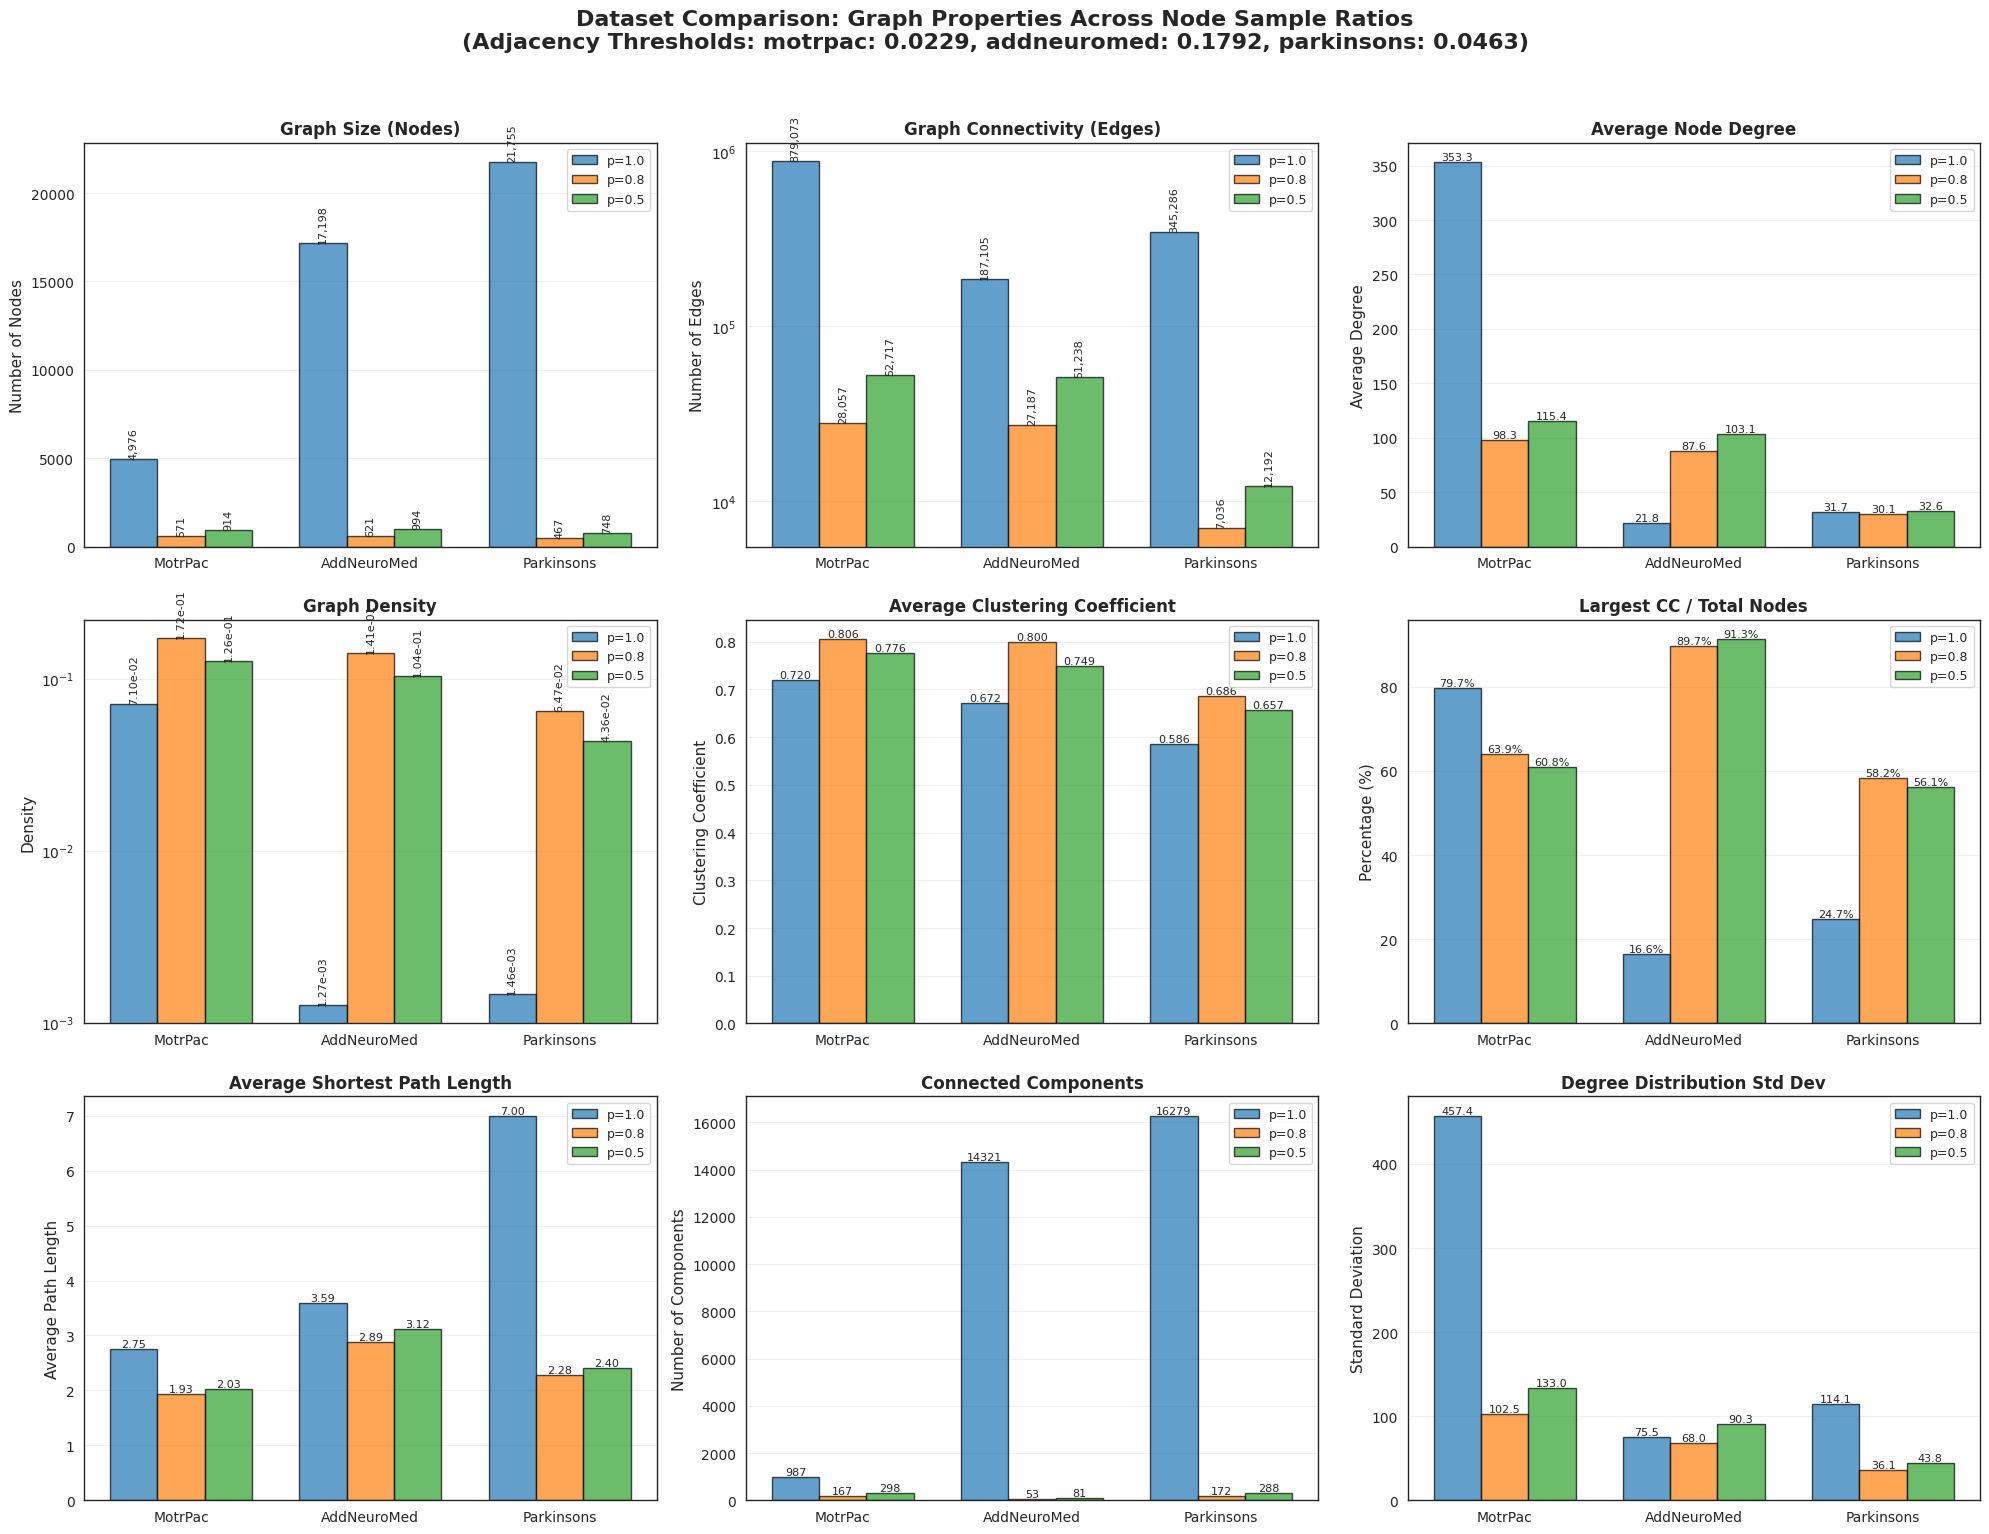

In [9]:
# Alternative: Create grouped bar charts comparing node_sample_ratio values
# This shows how graph properties change with different node sampling ratios

datasets_base = ["motrpac", "addneuromed", "parkinsons"]
node_sample_ratios = [1.0, 0.8, 0.5]
dataset_labels = {'motrpac': 'MotrPac', 'addneuromed': 'AddNeuroMed', 'parkinsons': 'Parkinsons'}
ratio_colors = {1.0: '#1f77b4', 0.8: '#ff7f0e', 0.5: '#2ca02c'}

# Get thresholds for title
thresholds_str = ", ".join([f"{d}: {dataset_thresholds[d]:.4f}" for d in datasets_base])

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle(f'Dataset Comparison: Graph Properties Across Node Sample Ratios\n(Adjacency Thresholds: {thresholds_str})', 
             fontsize=16, fontweight='bold', y=1.02)

x = np.arange(len(datasets_base))
width = 0.25  # Width of bars

# Helper function to get values for a metric
def get_values_for_metric(metric_name):
    values_by_ratio = {}
    for ratio in node_sample_ratios:
        values_by_ratio[ratio] = []
        for ds in datasets_base:
            key = f"{ds}_p{ratio}"
            if key in all_dataset_stats:
                values_by_ratio[ratio].append(all_dataset_stats[key][metric_name])
            else:
                values_by_ratio[ratio].append(0)
    return values_by_ratio

# Plot each metric with grouped bars
metrics_to_plot = [
    ('num_nodes', 'Number of Nodes', 'Graph Size (Nodes)', False, None),
    ('num_edges', 'Number of Edges', 'Graph Connectivity (Edges)', True, 'log'),
    ('avg_degree', 'Average Degree', 'Average Node Degree', False, None),
    ('density', 'Density', 'Graph Density', True, 'log'),
    ('clustering_coefficient', 'Clustering Coefficient', 'Average Clustering Coefficient', False, None),
    ('largest_cc_ratio', 'Percentage (%)', 'Largest CC / Total Nodes', False, None, lambda x: x * 100),
    ('avg_path_length', 'Average Path Length', 'Average Shortest Path Length', False, None),
    ('number_connected_components', 'Number of Components', 'Connected Components', False, None),
    ('degree_std', 'Standard Deviation', 'Degree Distribution Std Dev', False, None),
]

for idx, metric_info in enumerate(metrics_to_plot):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    metric_name, ylabel, title, use_log, scale_type = metric_info[:5]
    transform = metric_info[5] if len(metric_info) > 5 else None
    
    values_by_ratio = get_values_for_metric(metric_name)
    
    for i, ratio in enumerate(node_sample_ratios):
        offset = (i - 1) * width
        values = values_by_ratio[ratio]
        
        # Apply transform if specified (e.g., convert ratio to percentage)
        if transform:
            values = [transform(v) if not np.isnan(v) and v > 0 else 0 for v in values]
        else:
            values = [v if not np.isnan(v) else 0 for v in values]
        
        bars = ax.bar(x + offset, values, width,
                      label=f'p={ratio}', color=ratio_colors[ratio], alpha=0.7, edgecolor='black')
        
        # Add value labels
        for bar, val in zip(bars, values):
            if val > 0:
                height = bar.get_height()
                if metric_name == 'num_nodes':
                    label_text = f'{int(val):,}'
                    rotation = 90
                elif metric_name == 'num_edges':
                    label_text = f'{int(val):,}'
                    rotation = 90
                elif metric_name == 'density':
                    label_text = f'{val:.2e}'
                    rotation = 90
                elif metric_name == 'largest_cc_ratio':
                    label_text = f'{val:.1f}%'
                    rotation = 0
                elif metric_name == 'avg_path_length':
                    label_text = f'{val:.2f}'
                    rotation = 0
                elif metric_name == 'clustering_coefficient':
                    label_text = f'{val:.3f}'
                    rotation = 0
                elif metric_name == 'number_connected_components':
                    label_text = f'{int(val)}'
                    rotation = 0
                else:
                    label_text = f'{val:.1f}'
                    rotation = 0
                
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        label_text, ha='center', va='bottom', fontsize=8, rotation=rotation)
    
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([dataset_labels[d] for d in datasets_base])
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    if use_log and scale_type == 'log':
        ax.set_yscale('log')

plt.tight_layout()
plt.show()


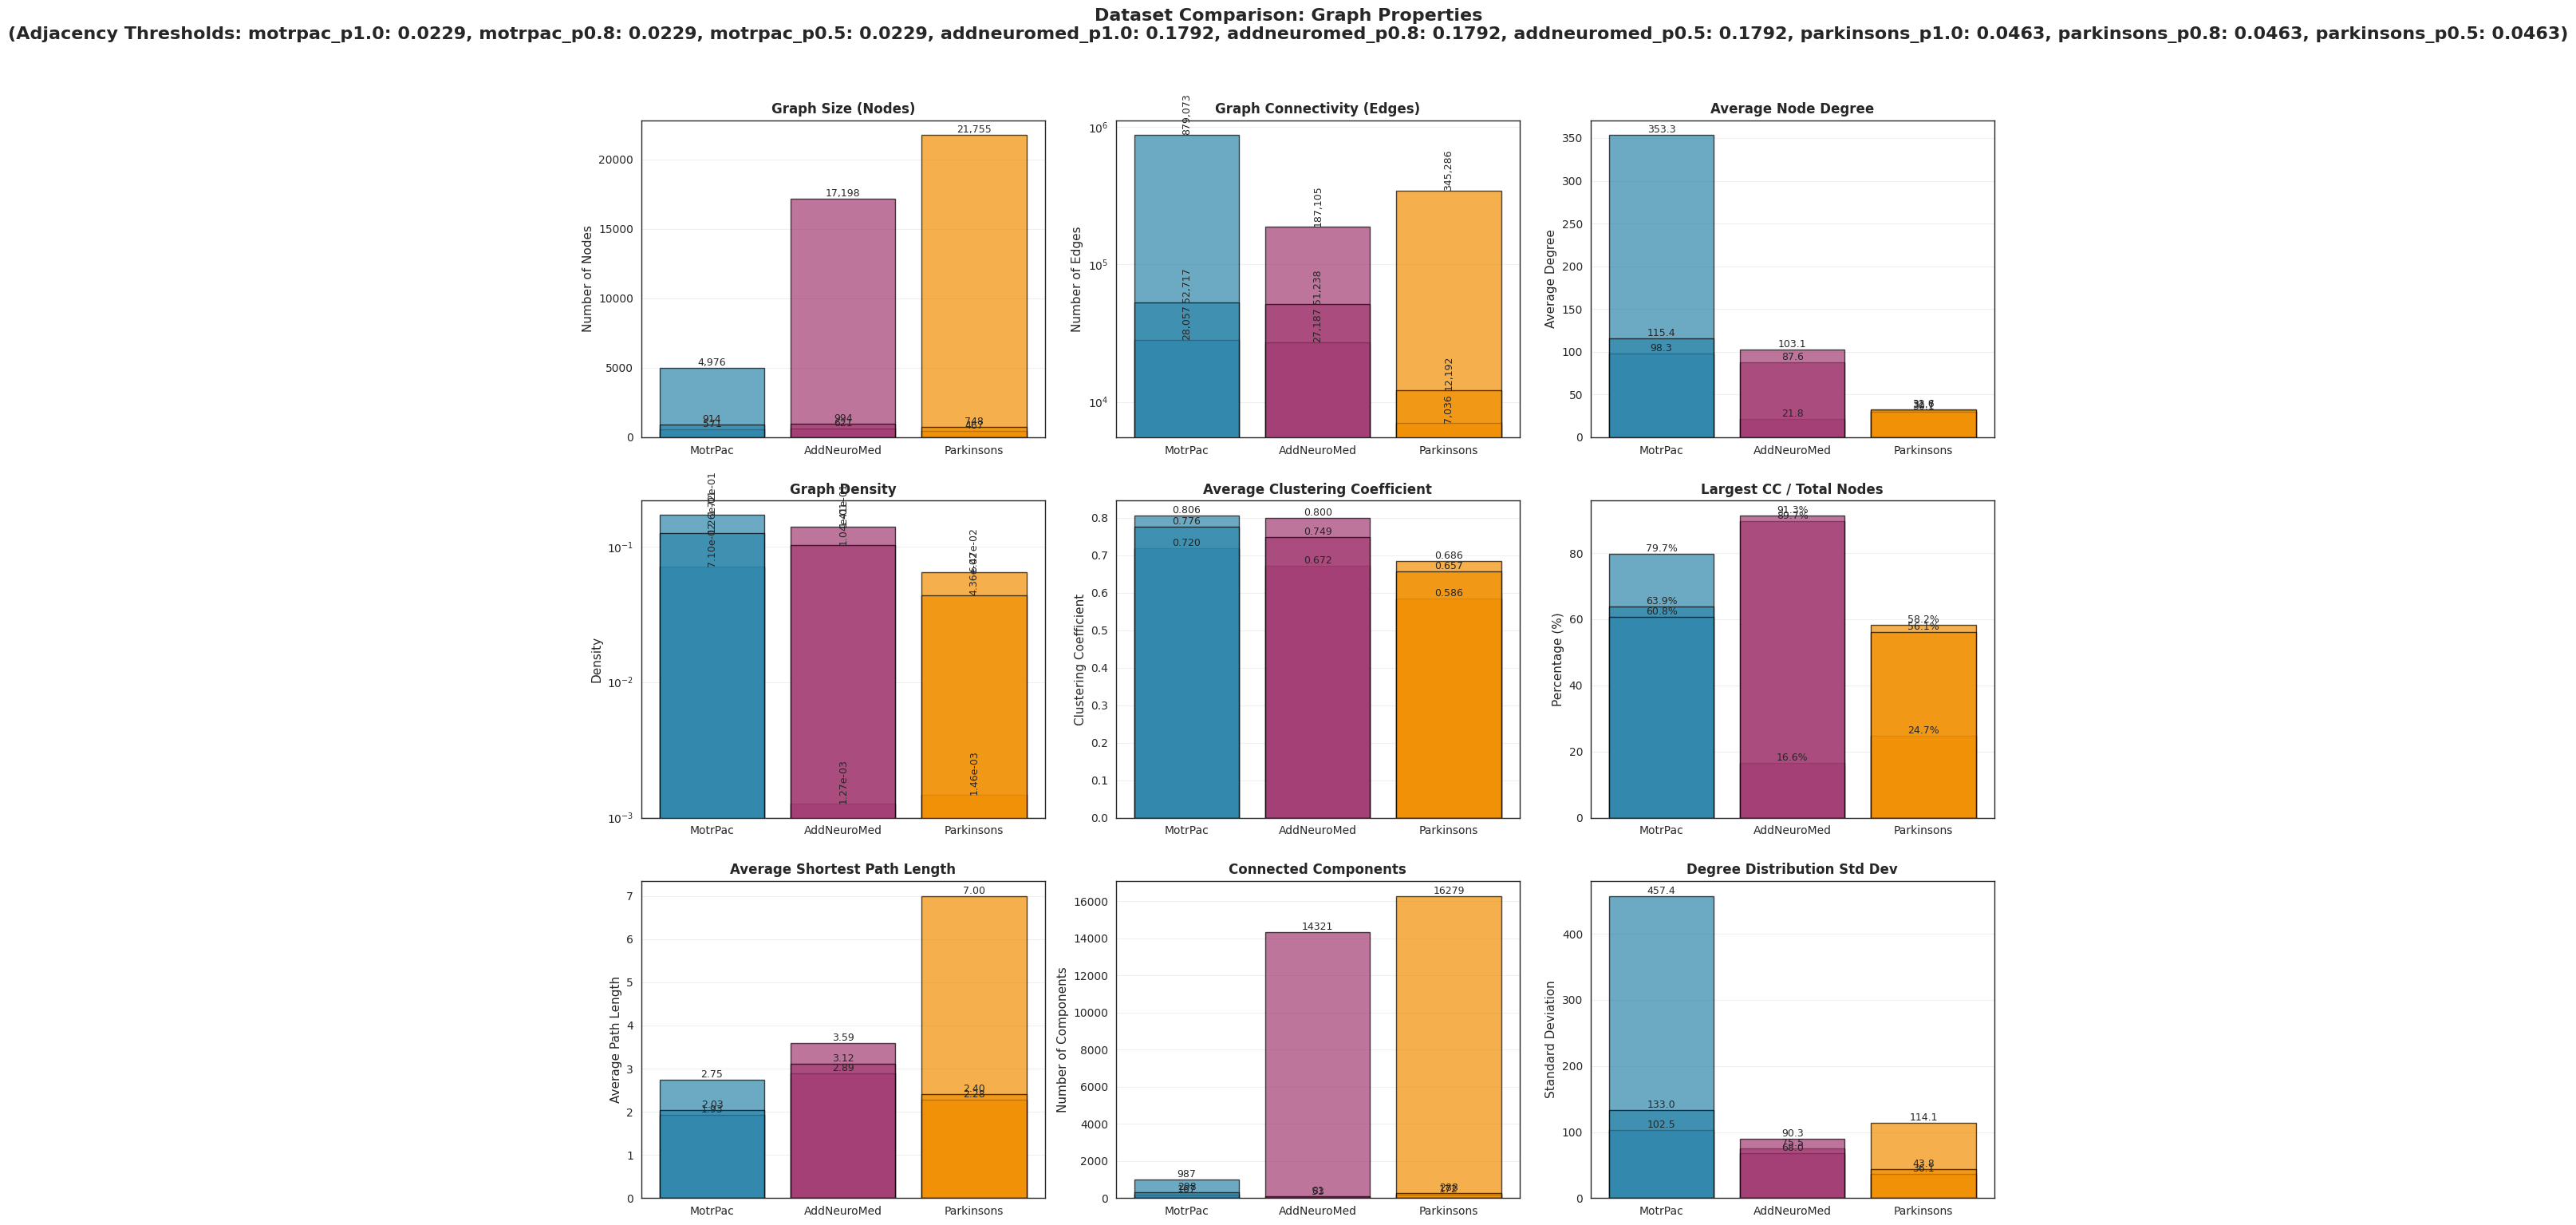

In [12]:
# Create comparative summary plots

# Helper function to extract base dataset name from key
def get_base_name(key):
    """Extract base dataset name from key like 'motrpac_p1.0' -> 'motrpac'"""
    return key.split('_p')[0]

datasets = list(all_dataset_stats.keys())

# Get the thresholds used for the title
thresholds_str = ", ".join([f"{d}: {all_dataset_stats[d]['adj_thresh']:.4f}" 
                            for d in datasets])
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle(f'Dataset Comparison: Graph Properties\n(Adjacency Thresholds: {thresholds_str})', 
             fontsize=16, fontweight='bold', y=1.02)
colors = {'motrpac': '#2E86AB', 'addneuromed': '#A23B72', 'parkinsons': '#F18F01'}
dataset_labels = {'motrpac': 'MotrPac', 'addneuromed': 'AddNeuroMed', 'parkinsons': 'Parkinsons'}

# 1. Number of Nodes
ax = axes[0, 0]
values = [all_dataset_stats[d]['num_nodes'] for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values, 
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Nodes', fontsize=11)
ax.set_title('Graph Size (Nodes)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9)

# 2. Number of Edges
ax = axes[0, 1]
values = [all_dataset_stats[d]['num_edges'] for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Edges', fontsize=11)
ax.set_title('Graph Connectivity (Edges)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9, rotation=90)

# 3. Average Degree
ax = axes[0, 2]
values = [all_dataset_stats[d]['avg_degree'] for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Average Degree', fontsize=11)
ax.set_title('Average Node Degree', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# 4. Graph Density
ax = axes[1, 0]
values = [all_dataset_stats[d]['density'] for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Graph Density', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2e}', ha='center', va='bottom', fontsize=9, rotation=90)

# 5. Clustering Coefficient
ax = axes[1, 1]
values = [all_dataset_stats[d]['clustering_coefficient'] for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Clustering Coefficient', fontsize=11)
ax.set_title('Average Clustering Coefficient', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 6. Largest Connected Component Ratio
ax = axes[1, 2]
values = [all_dataset_stats[d]['largest_cc_ratio'] * 100 for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Largest CC / Total Nodes', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# 7. Average Path Length (if available)
ax = axes[2, 0]
values = []
labels = []
for d in datasets:
    val = all_dataset_stats[d]['avg_path_length']
    base_name = get_base_name(d)
    if not np.isnan(val):
        values.append(val)
        labels.append(dataset_labels[base_name])
    else:
        values.append(0)
        labels.append(dataset_labels[base_name])
bars = ax.bar(labels, values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Average Path Length', fontsize=11)
ax.set_title('Average Shortest Path Length', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val, d in zip(bars, values, datasets):
    if not np.isnan(all_dataset_stats[d]['avg_path_length']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# 8. Number of Connected Components
ax = axes[2, 1]
values = [all_dataset_stats[d]['number_connected_components'] for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Components', fontsize=11)
ax.set_title('Connected Components', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val)}', ha='center', va='bottom', fontsize=9)

# 9. Degree Standard Deviation (shows heterogeneity)
ax = axes[2, 2]
values = [all_dataset_stats[d]['degree_std'] for d in datasets]
bars = ax.bar([dataset_labels[get_base_name(d)] for d in datasets], values,
              color=[colors[get_base_name(d)] for d in datasets], alpha=0.7, edgecolor='black')
ax.set_ylabel('Standard Deviation', fontsize=11)
ax.set_title('Degree Distribution Std Dev', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [13]:
# Create a summary table for easy comparison
summary_df = pd.DataFrame(all_dataset_stats).T
summary_df = summary_df[[
    'adj_thresh', 'num_nodes', 'num_edges', 'avg_degree', 'density',
    'clustering_coefficient', 'largest_cc_ratio', 'avg_path_length',
    'number_connected_components', 'degree_std'
]]

# Format the dataframe for better readability
summary_df.columns = [
    'Adj Threshold', 'Nodes', 'Edges', 'Avg Degree', 'Density',
    'Clustering Coeff', 'Largest CC Ratio', 'Avg Path Length',
    'Connected Components', 'Degree Std'
]

# Round numeric columns
for col in summary_df.columns:
    if summary_df[col].dtype in ['float64', 'float32']:
        if 'Threshold' in col:
            summary_df[col] = summary_df[col].apply(lambda x: f"{x:.4f}")
        elif 'Ratio' in col:
            summary_df[col] = summary_df[col].apply(lambda x: f"{x*100:.1f}%")
        elif 'Density' in col:
            summary_df[col] = summary_df[col].apply(lambda x: f"{x:.2e}")
        elif 'Coeff' in col:
            summary_df[col] = summary_df[col].apply(lambda x: f"{x:.4f}")
        elif 'Length' in col:
            summary_df[col] = summary_df[col].apply(lambda x: f"{x:.2f}" if not np.isnan(x) else "N/A")
        else:
            summary_df[col] = summary_df[col].apply(lambda x: f"{x:.2f}")
    else:
        summary_df[col] = summary_df[col].apply(lambda x: f"{int(x):,}")

print("\n" + "="*80)
print("COMPREHENSIVE DATASET COMPARISON TABLE")
print("="*80)
print(summary_df.to_string())
print("\n" + "="*80)
print("Key Insights:")
print("="*80)
print("\n1. Graph Size: Compare number of nodes and edges across datasets")
print("2. Connectivity: Density and average degree indicate how connected the graphs are")
print("3. Structure: Clustering coefficient shows local connectivity patterns")
print("4. Fragmentation: Connected components and largest CC ratio show graph cohesion")
print("5. Path Properties: Average path length indicates information flow efficiency")
print("\nNote: Each dataset uses its specific adjacency threshold:")
dataset_labels = {'motrpac': 'MotrPac', 'addneuromed': 'AddNeuroMed', 'parkinsons': 'Parkinsons'}
for d in all_dataset_stats.keys():
    print(f"   - {dataset_labels.get(d, d)}: {all_dataset_stats[d]['adj_thresh']:.4f}")
print("\n   MotrPac is the only dataset where graph models outperform MLP.")
print("   Look for properties that distinguish MotrPac from the others.")



COMPREHENSIVE DATASET COMPARISON TABLE
                 Adj Threshold   Nodes    Edges Avg Degree Density Clustering Coeff Largest CC Ratio Avg Path Length Connected Components Degree Std
motrpac_p1.0                 0   4,976  879,073        353       0                0                0               2                  987        457
motrpac_p0.8                 0     571   28,057         98       0                0                0               1                  167        102
motrpac_p0.5                 0     914   52,717        115       0                0                0               2                  298        133
addneuromed_p1.0             0  17,198  187,105         21       0                0                0               3               14,321         75
addneuromed_p0.8             0     621   27,187         87       0                0                0               2                   53         67
addneuromed_p0.5             0     994   51,238        103       0

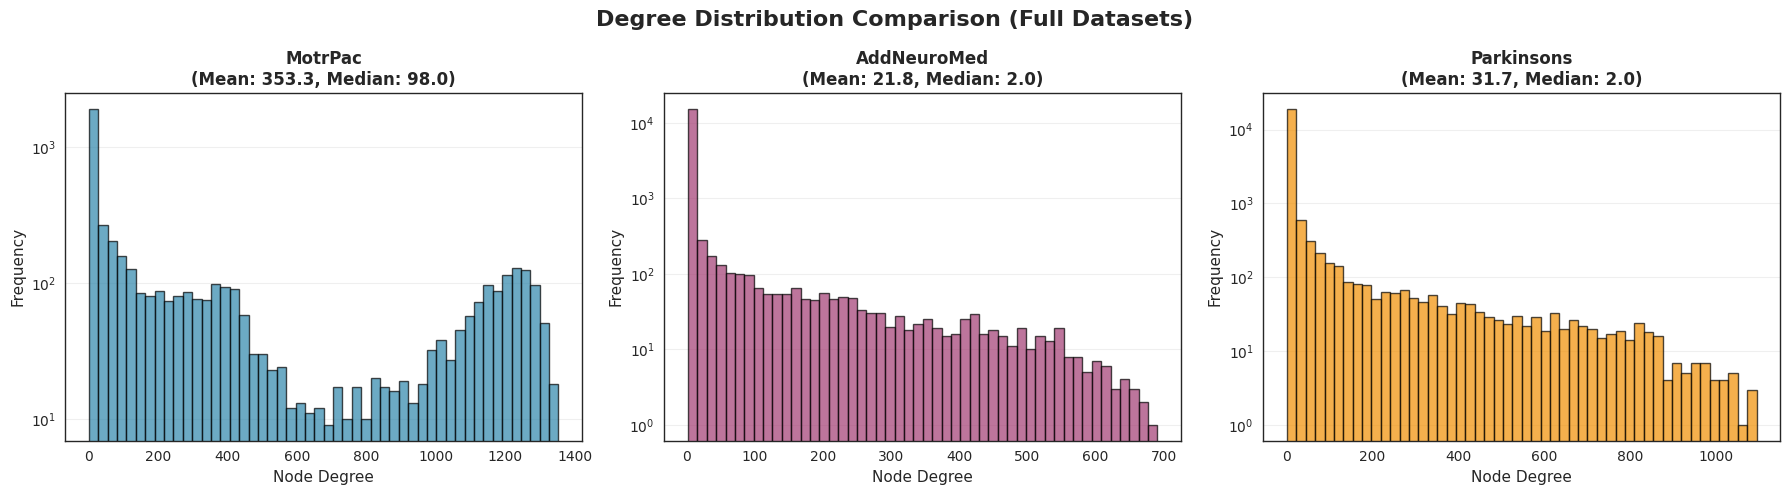

In [15]:
# Additional analysis: Degree distribution comparison
# Plot only the full datasets (p1.0) for clarity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Degree Distribution Comparison (Full Datasets)', fontsize=16, fontweight='bold')

# Filter to only full datasets (p1.0)
datasets = [d for d in all_dataset_stats.keys() if d.endswith('_p1.0')]

for idx, dataset_name in enumerate(datasets):
    ax = axes[idx]
    base_name = get_base_name(dataset_name)
    
    # Use the stored dataset object to get the graph
    if dataset_name in loaded_datasets:
        dataset = loaded_datasets[dataset_name]
        
        try:
            # Try to get graph from processed data first
            graph = None
            if hasattr(dataset, 'data') and dataset.data is not None:
                data = dataset[0]
                edge_index = data.edge_index
                num_nodes = data.x.shape[0]
                
                # Convert edge_index to numpy if it's a torch tensor
                if hasattr(edge_index, 'numpy'):
                    edge_list = edge_index.t().numpy()
                elif hasattr(edge_index, 'cpu'):
                    edge_list = edge_index.cpu().numpy().T
                else:
                    edge_list = edge_index.T
                
                graph = nx.Graph()
                graph.add_nodes_from(range(num_nodes))
                graph.add_edges_from(edge_list)
            
            # Fallback to raw_dir
            if graph is None and hasattr(dataset, 'raw_dir'):
                adj_path = osp.join(dataset.raw_dir, 'adj_matrix.npy')
                if osp.exists(adj_path):
                    adj_matrix = np.load(adj_path)
                    graph = nx.from_numpy_array(adj_matrix)
                    graph.remove_edges_from(nx.selfloop_edges(graph))
            
            if graph is not None:
                degrees = [d for _, d in graph.degree()]
                
                # Plot histogram
                ax.hist(degrees, bins=50, color=colors[base_name], alpha=0.7, edgecolor='black')
                ax.set_xlabel('Node Degree', fontsize=11)
                ax.set_ylabel('Frequency', fontsize=11)
                ax.set_title(f'{dataset_labels[base_name]}\n(Mean: {np.mean(degrees):.1f}, Median: {np.median(degrees):.1f})', 
                            fontsize=12, fontweight='bold')
                ax.grid(axis='y', alpha=0.3)
                ax.set_yscale('log')
            else:
                ax.text(0.5, 0.5, 'Could not load graph data', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(dataset_labels[base_name], fontsize=12, fontweight='bold')
        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading\ndata: {str(e)[:50]}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(dataset_labels[base_name], fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Dataset not loaded', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(dataset_labels[base_name], fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Save comprehensive statistics to CSV for further analysis
output_dir = "./stats/comparison"
os.makedirs(output_dir, exist_ok=True)

# Create a detailed dataframe
detailed_df = pd.DataFrame(all_dataset_stats).T
detailed_df.index.name = 'dataset'

output_file = osp.join(output_dir, "dataset_comparison_stats.csv")
detailed_df.to_csv(output_file)
print(f"\n✓ Comprehensive statistics saved to: {output_file}")

# Also create a formatted summary CSV
summary_output = osp.join(output_dir, "dataset_comparison_summary.csv")
summary_df.to_csv(summary_output)
print(f"✓ Summary table saved to: {summary_output}")



✓ Comprehensive statistics saved to: ./stats/comparison/dataset_comparison_stats.csv
✓ Summary table saved to: ./stats/comparison/dataset_comparison_summary.csv
